## Step 01: Setup Environment

In [5]:
#check the python version and env and the pytorch version
import sys
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)


Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.5.1


## Step 02: Exploratory Data Analysis

In [12]:
#load the tex file and print the first 100 characters

print("Loading data...")
print("====================================================================")
print("Train data:")
print("====================================================================")
with open("./data/train.txt", "r") as f:
    data = f.read()
    print(data[:100])


print("====================================================================")
print("Validation data:")
print("====================================================================")
with open("./data/val.txt", "r") as f:
    data = f.read()
    print(data[:100])

print("====================================================================")
print("Test data:")
print("====================================================================")
with open("./data/test.txt", "r") as f:
    data = f.read()
    print(data[:100])

Loading data...
Train data:
Selegiline	O
-	O
induced	O
postural	B-Disease
hypotension	I-Disease
in	O
Parkinson	B-Disease
'	I-Dis
Validation data:
22	O
-	O
oxacalcitriol	O
suppresses	O
secondary	B-Disease
hyperparathyroidism	I-Disease
without	O
in
Test data:
Torsade	B-Disease
de	I-Disease
pointes	I-Disease
ventricular	B-Disease
tachycardia	I-Disease
during	


In [13]:
import os
import json

def parse_ner_file(file_path):
  
    sentences = []
    current_words = []
    current_labels = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            
            if not line:
                if current_words:
                    sentences.append({
                        "words": current_words,
                        "labels": current_labels
                    })
                    current_words = []
                    current_labels = []
                continue
            
        
            parts = line.split()
            if len(parts) >= 2:
                word = parts[0]
                label = parts[-1] 
                current_words.append(word)
                current_labels.append(label)
                
        
        if current_words:
            sentences.append({
                "words": current_words,
                "labels": current_labels
            })
            
    return sentences


In [ ]:
# --- Main Execution ---
data_dir = "./data"
output_dir = "./processed_base_data"
os.makedirs(output_dir, exist_ok=True)

files_to_process = ["train.txt", "val.txt", "test.txt"]

for file_name in files_to_process:
    input_path = os.path.join(data_dir, file_name)
    
    if os.path.exists(input_path):
        print(f"Processing {file_name}...")
        parsed_data = parse_ner_file(input_path)
        
        output_name = file_name.replace(".txt", ".json")
        output_path = os.path.join(output_dir, output_name)
        
        with open(output_path, "w", encoding="utf-8") as out_f:
            json.dump(parsed_data, out_f, indent=4)
            
        print(f"Successfully saved {len(parsed_data)} sentences to {output_path}")
    else:
        print(f"Error: {input_path} !")

print("====================================================================")
print("Base Data Preparation Done!")

Processing train.txt...
Successfully saved 4560 sentences to ./processed_base_data\train.json
Processing val.txt...
Successfully saved 4581 sentences to ./processed_base_data\val.json
Processing test.txt...
Successfully saved 4797 sentences to ./processed_base_data\test.json
Base Data Preparation Done!


In [17]:
with open("./processed_base_data/train.json", "r") as f:
    train_dataset = json.load(f)

print("First Sentence Words:", train_dataset[0]["words"])
print("First Sentence Labels:", train_dataset[0]["labels"])

First Sentence Words: ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']
First Sentence Labels: ['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [18]:
import json
import os

# Define the file paths for verification
data_files = {
    "Train Data": "./processed_base_data/train.json",
    "Validation Data": "./processed_base_data/val.json",
    "Test Data": "./processed_base_data/test.json"
}

print("Starting structural validation for dataset splits...")
print("====================================================================")

all_splits_valid = True

for split_name, file_path in data_files.items():
    if not os.path.exists(file_path):
        print(f"Warning: {split_name} file not found at {file_path}. Skipping...")
        continue
        
    print(f"Verifying {split_name}...")
    
    # Load the processed JSON data
    with open(file_path, "r", encoding="utf-8") as f:
        dataset = json.load(f)
        
    mismatched_sentences_count = 0
    total_sentences = len(dataset)
    
    # Loop through each sentence to check lengths
    for index, sample in enumerate(dataset):
        word_length = len(sample["words"])
        label_length = len(sample["labels"])
        
        # Check if the length of words matches the length of labels
        if word_length != label_length:
            print(f"  [Error] Mismatch found at sentence index {index}!")
            print(f"  Words ({word_length}): {sample['words']}")
            print(f"  Labels ({label_length}): {sample['labels']}")
            print("-" * 50)
            mismatched_sentences_count += 1
            all_splits_valid = False

    # Print summary statistics for the current split
    if mismatched_sentences_count == 0:
        print(f"  [Success] All {total_sentences} sentences are structurally sound.")
        print(f"  --> Word count and Tag count match perfectly for all sequences.")
    else:
        print(f"  [Failure] Found {mismatched_sentences_count} mismatched sequences out of {total_sentences}.")
        
    print("====================================================================")

# Final confirmation block
if all_splits_valid:
    print("Status Check: PASSED. Datasets are ready for the embedding pipelines!")
else:
    print("Status Check: FAILED. Please resolve the mismatched lengths before proceeding.")

Starting structural validation for dataset splits...
Verifying Train Data...
  [Success] All 4560 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Validation Data...
  [Success] All 4581 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Test Data...
  [Success] All 4797 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Status Check: PASSED. Datasets are ready for the embedding pipelines!


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")


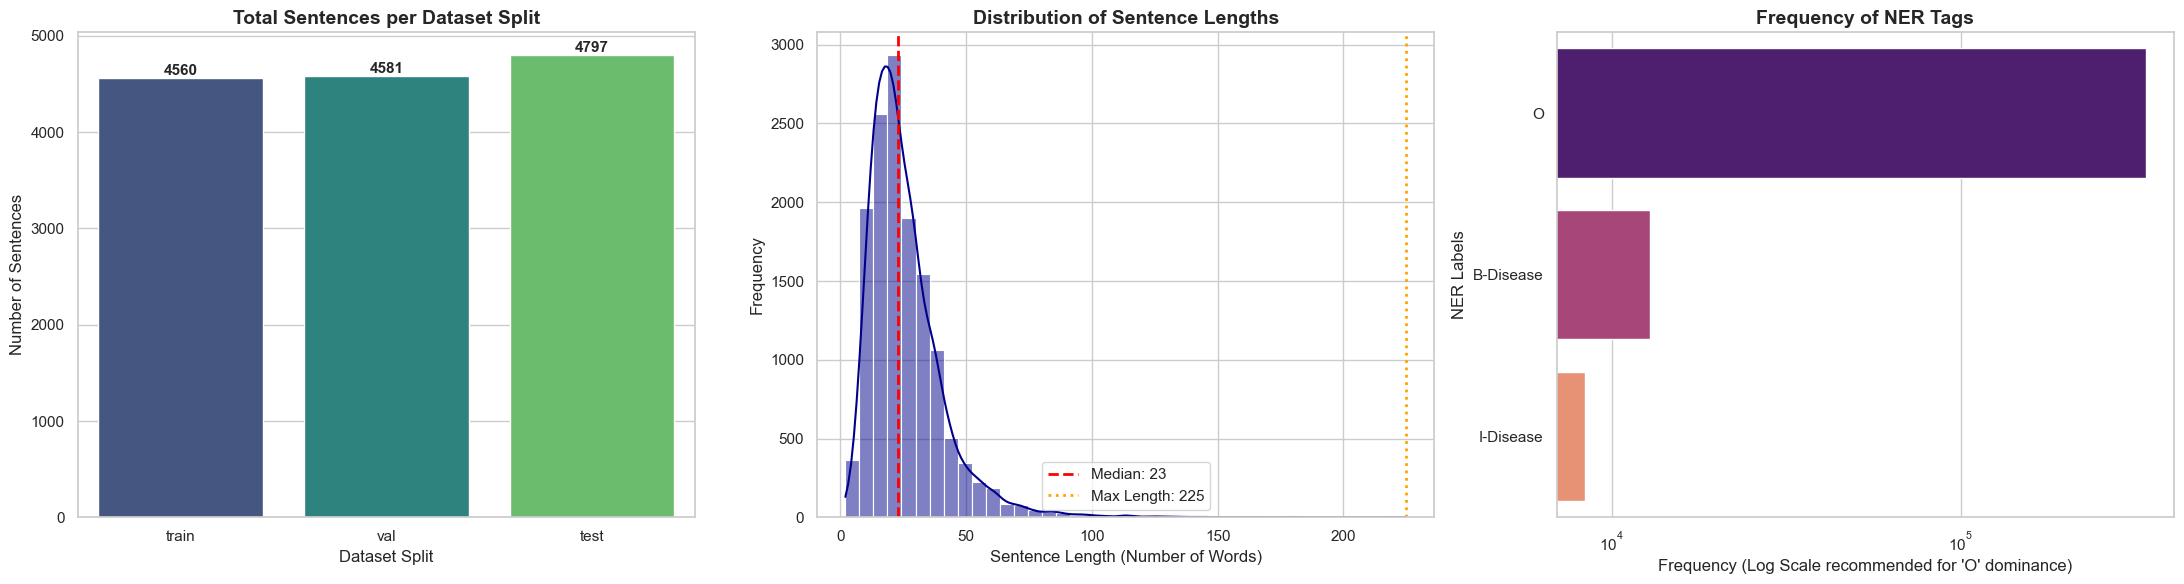

Data Insights Summary Table:
Total Combined Sentences : 13938
Maximum Sentence Length  : 225 words
Median Sentence Length   : 23 words
--------------------------------------------------------------------
NER Tag Frequencies:
  O            : 339,143 occurrences
  B-Disease    : 12,852 occurrences
  I-Disease    : 8,378 occurrences


In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. Load all processed JSON datasets
splits = ["train", "val", "test"]
datasets = {}

for split in splits:
    with open(f"./processed_base_data/{split}.json", "r", encoding="utf-8") as f:
        datasets[split] = json.load(f)

# 2. Extract statistics for plotting
split_counts = {split: len(datasets[split]) for split in splits}

sentence_lengths = []
all_tags = []

for split in splits:
    for sample in datasets[split]:
        # Track sequence lengths (word counts)
        sentence_lengths.append(len(sample["words"]))
        # Track all NER tags (excluding structural symbols if any, but keeping standard tags)
        all_tags.extend(sample["labels"])

# Convert tag list to a frequency distribution dictionary
tag_counts = Counter(all_tags)

# 3. Setup the plotting canvas (3 distinct subplots)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot A: Total Sentence Count per Dataset Split ---
sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
axes[0].set_title("Total Sentences per Dataset Split", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dataset Split", fontsize=12)
axes[0].set_ylabel("Number of Sentences", fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=11, fontweight="bold")

# --- Plot B: Sentence Length Distribution (Sequence Length Analysis) ---
sns.histplot(sentence_lengths, bins=40, kde=True, ax=axes[1], color="darkblue")
axes[1].set_title("Distribution of Sentence Lengths", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sentence Length (Number of Words)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Calculate and overlay median/max sequence stats
median_len = pd.Series(sentence_lengths).median()
max_len = max(sentence_lengths)
axes[1].axvline(median_len, color="red", linestyle="--", linewidth=2, label=f"Median: {int(median_len)}")
axes[1].axvline(max_len, color="orange", linestyle=":", linewidth=2, label=f"Max Length: {max_len}")
axes[1].legend(fontsize=11)

# --- Plot C: NER Label/Tag Distribution Frequency ---
# Convert to DataFrame for easier plotting with Seaborn
tag_df = pd.DataFrame(tag_counts.items(), columns=["Tag", "Frequency"]).sort_values(by="Frequency", ascending=False)
sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")
axes[2].set_title("Frequency of NER Tags", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Frequency (Log Scale recommended for 'O' dominance)", fontsize=12)
axes[2].set_ylabel("NER Labels", fontsize=12)
axes[2].set_xscale("log")  # Using log scale since 'O' tags completely dominate entity tags

# 4. Render and adjust layout
plt.tight_layout()
plt.show()

# 5. Print a quick text summary for confirmation
print("====================================================================")
print("Data Insights Summary Table:")
print("====================================================================")
print(f"Total Combined Sentences : {sum(split_counts.values())}")
print(f"Maximum Sentence Length  : {max_len} words")
print(f"Median Sentence Length   : {int(median_len)} words")
print("--------------------------------------------------------------------")
print("NER Tag Frequencies:")
for tag, count in tag_df.values:
    print(f"  {tag:<12} : {count:,} occurrences")
print("====================================================================")

## Step 03: Tokenization

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ravin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [5]:
import os
import json
import pickle
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer

print("Initializing tokenization and label alignment pipeline...")
print("====================================================================")

# Load the standard BERT tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Define target splits and directories
target_splits = ["train", "val", "test"]
output_base_dir = "./tokenized_data"

# Create separate subdirectories for each tokenizer type
tokenizer_types = ["whitespace", "nltk", "wordpiece"]
for t_type in tokenizer_types:
    os.makedirs(os.path.join(output_base_dir, t_type), exist_ok=True)

# Loop through each dataset split (Train, Val, Test)
for split in target_splits:
    input_file_path = f"./processed_base_data/{split}.json"
    
    if not os.path.exists(input_file_path):
        print(f"Warning: Base file {input_file_path} not found. Skipping...")
        continue
        
    print(f"Processing split: '{split}'...")
    
    with open(input_file_path, "r", encoding="utf-8") as f:
        sentences_data = json.load(f)
        
    whitespace_records = []
    nltk_records = []
    wordpiece_records = []
    
    for record in sentences_data:
        raw_words = record["words"]
        raw_labels = record["labels"]
        
        # Reconstruct original sentence sequence from list of words
        raw_sentence_string = " ".join(raw_words)
        
        # -----------------------------------------------------------------
        # 1. Pipeline: Whitespace Tokenization
        # -----------------------------------------------------------------
        whitespace_tokens = raw_sentence_string.split()
        whitespace_labels = raw_labels[:len(whitespace_tokens)]
        whitespace_records.append({"tokens": whitespace_tokens, "labels": whitespace_labels})
        
        # -----------------------------------------------------------------
        # 2. Pipeline: NLTK Tokenization
        # -----------------------------------------------------------------
        nltk_tokens = word_tokenize(raw_sentence_string)
        nltk_labels = []
        word_index = 0
        for token in nltk_tokens:
            if word_index < len(raw_labels):
                nltk_labels.append(raw_labels[word_index])
                word_index += 1
            else:
                nltk_labels.append("O")
        nltk_records.append({"tokens": nltk_tokens, "labels": nltk_labels})
        
        # -----------------------------------------------------------------
        # 3. Pipeline: BERT WordPiece Tokenization (Sub-word Alignment with I- Tags)
        # -----------------------------------------------------------------
        tokenized_input = bert_tokenizer(raw_sentence_string, is_split_into_words=False)
        wordpiece_tokens = bert_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        
        wordpiece_labels = []
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                # Assign 'O' to BERT special tokens ([CLS], [SEP])
                wordpiece_labels.append("O")
            elif word_idx != previous_word_idx:
                # First sub-word token retains the original entity tag
                wordpiece_labels.append(raw_labels[word_idx])
            else:
                # Subsequent sub-word fragments are converted to 'I-' tags
                original_tag = raw_labels[word_idx]
                if original_tag.startswith("B-"):
                    # Convert B-Disease to I-Disease for alignment continuity
                    wordpiece_labels.append("I-" + original_tag[2:])
                else:
                    wordpiece_labels.append(original_tag)
            previous_word_idx = word_idx
            
        wordpiece_records.append({"tokens": wordpiece_tokens, "labels": wordpiece_labels})
        
    # Serialize and save the processed lists to disk
    with open(f"{output_base_dir}/whitespace/{split}.pkl", "wb") as out_f:
        pickle.dump(whitespace_records, out_f)
        
    with open(f"{output_base_dir}/nltk/{split}.pkl", "wb") as out_f:
        pickle.dump(nltk_records, out_f)
        
    with open(f"{output_base_dir}/wordpiece/{split}.pkl", "wb") as out_f:
        pickle.dump(wordpiece_records, out_f)
        
    print(f"  --> Successfully saved pickle objects for '{split}' split.")
    print("-" * 50)

print("Pipeline execution completed successfully. All artifacts are serialized!")

Initializing tokenization and label alignment pipeline...
Processing split: 'train'...
  --> Successfully saved pickle objects for 'train' split.
--------------------------------------------------
Processing split: 'val'...
  --> Successfully saved pickle objects for 'val' split.
--------------------------------------------------
Processing split: 'test'...
  --> Successfully saved pickle objects for 'test' split.
--------------------------------------------------
Pipeline execution completed successfully. All artifacts are serialized!


In [6]:
import pickle
import os

# Define the directory structure to scan and verify
base_serialized_dir = "./tokenized_data"
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
dataset_splits = ["train", "val", "test"]

print("Starting deep structure verification on serialized pickle artifacts...")
print("====================================================================")

global_pipeline_valid = True

# Iterate through each tokenizer directory
for tokenizer in tokenizer_pipelines:
    print(f"Checking Pipeline: {tokenizer.upper()}")
    print("-" * 50)
    
    for split in dataset_splits:
        file_path = os.path.join(base_serialized_dir, tokenizer, f"{split}.pkl")
        
        if not os.path.exists(file_path):
            print(f"  [Warning] File missing: {file_path}")
            continue
            
        # Load the serialized data records
        with open(file_path, "rb") as f:
            serialized_records = pickle.load(f)
            
        mismatch_count = 0
        total_records = len(serialized_records)
        
        # Verify sequence continuity for every single token-label pair
        for idx, record in enumerate(serialized_records):
            token_count = len(record["tokens"])
            label_count = len(record["labels"])
            
            if token_count != label_count:
                print(f"    [Length Mismatch] Found at {split}.pkl | Index: {idx}")
                print(f"    Tokens ({token_count}): {record['tokens'][:5]}...")
                print(f"    Labels ({label_count}): {record['labels'][:5]}...")
                mismatch_count += 1
                global_pipeline_valid = False
                
        # Print results summary for this specific file
        if mismatch_count == 0:
            print(f"  --> Split '{split:<5}' : PASSED (All {total_records:,} sequences match perfectly).")
        else:
            print(f"  --> Split '{split:<5}' : FAILED ({mismatch_count} anomalies detected out of {total_records:,}).")
            
    print("====================================================================")

# Final pipeline validation response
if global_pipeline_valid:
    print("Verification Status: ALL PASSED. Token-Label counts are perfectly synced across all 3 pipelines!")
else:
    print("Verification Status: ERROR DETECTED. Please check the mismatches reported above.")

Starting deep structure verification on serialized pickle artifacts...
Checking Pipeline: WHITESPACE
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Checking Pipeline: NLTK
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Checking Pipeline: WORDPIECE
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Verification Status: ALL PASSED. Token-Label counts are perfectly synced across a

Analyzing tokenized artifacts for Exploratory Data Analysis...


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2760088588.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(vocab_stats.keys()), y=list(vocab_stats.values()), ax=axes[0], palette="coolwarm")


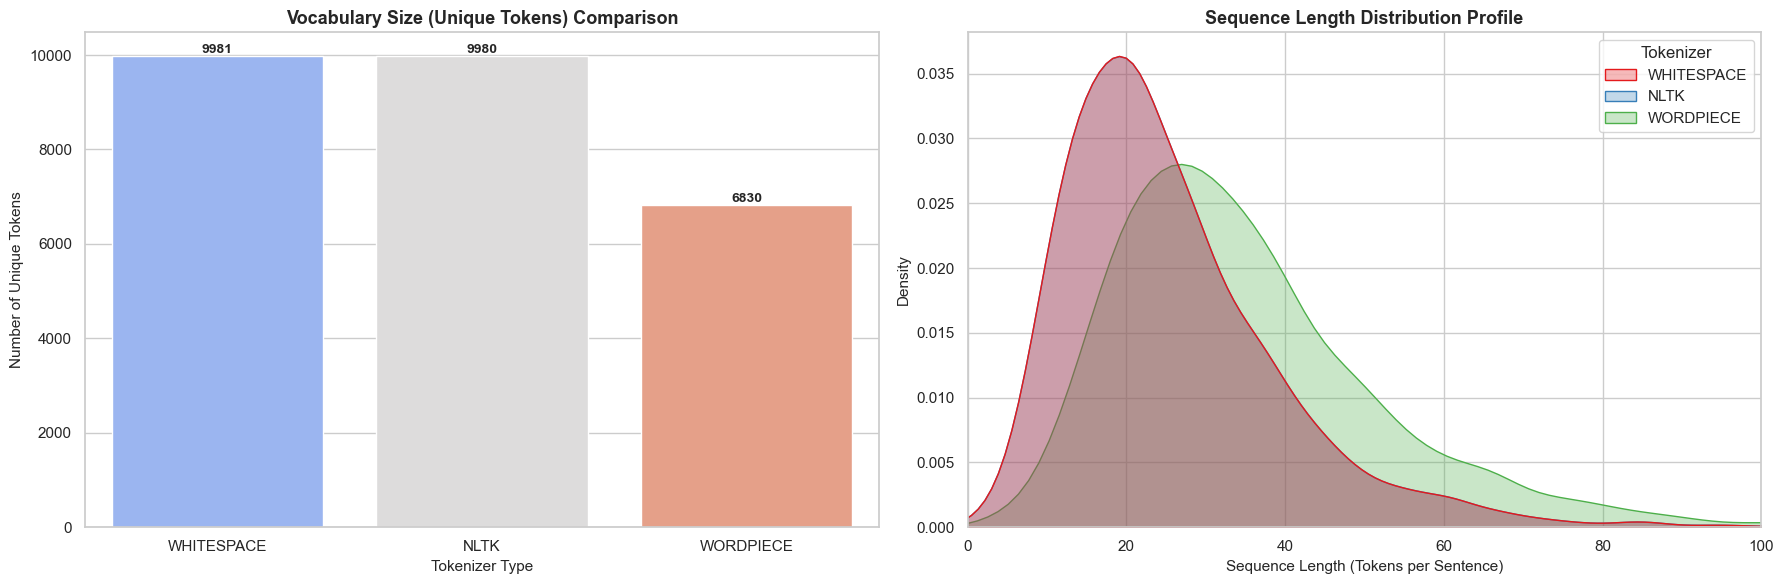

Tokenization Profile Insights Table:
Tokenizer: WHITESPACE 
  -> Unique Vocabulary Size : 9,981
  -> Median Sequence Length : 23 tokens
  -> Maximum Sequence Length: 154 tokens
--------------------------------------------------
Tokenizer: NLTK       
  -> Unique Vocabulary Size : 9,980
  -> Median Sequence Length : 23 tokens
  -> Maximum Sequence Length: 154 tokens
--------------------------------------------------
Tokenizer: WORDPIECE  
  -> Unique Vocabulary Size : 6,830
  -> Median Sequence Length : 32 tokens
  -> Maximum Sequence Length: 239 tokens
--------------------------------------------------


In [7]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define paths for the tokenized train splits
base_serialized_dir = "./tokenized_data"
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

# Data structures to collect insights
vocab_stats = {}
length_records = []

print("Analyzing tokenized artifacts for Exploratory Data Analysis...")
print("====================================================================")

for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    with open(file_path, "rb") as f:
        records = pickle.load(f)
        
    unique_tokens = set()
    
    for record in records:
        tokens_list = record["tokens"]
        # Track sequence length for this sentence
        length_records.append({
            "Tokenizer": tokenizer.upper(),
            "Sequence Length": len(tokens_list)
        })
        # Add tokens to set to calculate unique vocabulary size
        for token in tokens_list:
            unique_tokens.add(token)
            
    vocab_stats[tokenizer.upper()] = len(unique_tokens)

# Convert sequence lengths to a Pandas DataFrame for plotting
df_lengths = pd.DataFrame(length_records)

# Setup plotting canvas with 2 subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot A: Vocabulary Size Comparison across Tokenizers ---
sns.barplot(x=list(vocab_stats.keys()), y=list(vocab_stats.values()), ax=axes[0], palette="coolwarm")
axes[0].set_title("Vocabulary Size (Unique Tokens) Comparison", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tokenizer Type", fontsize=11)
axes[0].set_ylabel("Number of Unique Tokens", fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10, fontweight="bold")

# --- Plot B: Sequence Length Distribution Density Plot ---
sns.kdeplot(data=df_lengths, x="Sequence Length", hue="Tokenizer", fill=True, common_norm=False, palette="Set1", alpha=0.3, ax=axes[2-1])
axes[1].set_title("Sequence Length Distribution Profile", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Sequence Length (Tokens per Sentence)", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].set_xlim(0, 100) # Limiting X-axis to 100 for better visualization of the bulk data

plt.tight_layout()
plt.show()

# Print text summary report
print("====================================================================")
print("Tokenization Profile Insights Table:")
print("====================================================================")
for tokenizer in tokenizer_pipelines:
    t_name = tokenizer.upper()
    t_df = df_lengths[df_lengths["Tokenizer"] == t_name]
    print(f"Tokenizer: {t_name:<11}")
    print(f"  -> Unique Vocabulary Size : {vocab_stats[t_name]:,}")
    print(f"  -> Median Sequence Length : {int(t_df['Sequence Length'].median())} tokens")
    print(f"  -> Maximum Sequence Length: {int(t_df['Sequence Length'].max())} tokens")
    print("-" * 50)

## Step:04 Embedding Generation

### Word2Vec Embedding

#### Word2Vec with Whitespace Tokenizer

In [15]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized whitespace tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed train data split
whitespace_train_path = "./tokenized_data/whitespace/train.pkl"

if os.path.exists(whitespace_train_path):
    with open(whitespace_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract only the token sequences (sentences) for Word2Vec training
    sentences_for_w2v = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v):,} sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {whitespace_train_path}. Please check data pipeline execution.")
    sentences_for_w2v = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model with extended epochs
if sentences_for_w2v:
    print("Training Custom Word2Vec model (Embedding Dimension: 300 | Epochs: 15)...")
    
    w2v_model = Word2Vec(
        sentences=sentences_for_w2v,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local token relationships
        min_count=1,          # Ensure every single token in the training split is mapped
        workers=4,            # Enable multi-threaded execution for modern CPU architectures
        sg=1,                 # Skip-gram formulation (highly optimized for rare NER entities)
        epochs=15             # Extended epochs for better convergence
    )
    
    print("Custom model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Multi-Category Intrinsic Validation Check via Cosine Similarity
    print("Running multi-category intrinsic validation check...")
    print("--------------------------------------------------------------------")
    
    # Defining diverse token categories to evaluate semantic understanding
    validation_queries = {
        "Disease Entity": "hypotension",
        "Stopword/Preposition": "in",
        "Anatomical/Organ Term": "renal",
        "General Medical Concept": "drug"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. UPDATED: Save directly into trained_embeddings/word2vec with correct naming
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withwhitespace_300.model")
    
    w2v_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized whitespace tokenized data for Word2Vec training...
Successfully loaded 4,560 sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model (Embedding Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom model training completed successfully with 15 epochs!
Running multi-category intrinsic validation check...
--------------------------------------------------------------------
Category: DISEASE ENTITY | Target Token: 'hypotension'
  Top 5 tokens most semantically similar:
    -> haemodilution   : 0.8061
    -> bradycardia     : 0.7888
    -> orthostatic     : 0.7806
    -> nitroglycerin   : 0.7700
    -> convulsions     : 0.7606
--------------------------------------------------
Category: STOPWORD/PREPOSITION | Target Token: 'in'
  Top 5 tokens most semantically similar:
    -> young           : 0.5692
    -> lesion          : 0.5675
    -> exhibited       : 0.5669
    -> AIDS            : 0.5653
    -> diabetic        : 0.5592
--------------------------------------------------
Category: ANATOMICAL/ORGAN TERM | Target Token: 'renal'
  Top 5 tokens most semantically similar:
    -> failure         : 0.7355
    -> insufficiency   : 0.7302
    -> liver           : 0.7236
    -> all

#### Word2Vec with WordPiece

In [16]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized WordPiece (BERT) tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed WordPiece train data split
wordpiece_train_path = "./tokenized_data/wordpiece/train.pkl"

if os.path.exists(wordpiece_train_path):
    with open(wordpiece_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract sub-word token sequences (sentences) for Word2Vec training
    sentences_for_w2v_wp = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v_wp):,} WordPiece sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {wordpiece_train_path}. Please check data pipeline execution.")
    sentences_for_w2v_wp = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model on Sub-words (WordPiece)
if sentences_for_w2v_wp:
    print("Training Custom Word2Vec model on WordPiece tokens (Dimension: 300 | Epochs: 15)...")
    
    w2v_wp_model = Word2Vec(
        sentences=sentences_for_w2v_wp,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local sub-word relationships
        min_count=1,          # Ensure every sub-word fragment in training split is mapped
        workers=4,            # Enable multi-threaded execution
        sg=1,                 # Skip-gram formulation (highly optimized for rare sub-words)
        epochs=15             # Match 15 epochs for structural consistency
    )
    
    print("Custom Word2Vec (WordPiece) model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Custom Sub-word Intrinsic Validation Check via Cosine Similarity
    print("Running sub-word semantic alignment verification check...")
    print("--------------------------------------------------------------------")
    
    # Target queries includes full words, prefixes, and BERT sub-word suffixes (##)
    validation_queries = {
        "Full Disease Word": "hypotension",
        "Sub-word Prefix": "hypo",
        "Sub-word Suffix (Disease)": "##tension",
        "Sub-word Suffix (Inflammation)": "##itis"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_wp_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_wp_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from sub-word vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. UPDATED: Save directly into trained_embeddings/word2vec with correct naming
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withwordpiece_300.model")
    
    w2v_wp_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized WordPiece (BERT) tokenized data for Word2Vec training...
Successfully loaded 4,560 WordPiece sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model on WordPiece tokens (Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom Word2Vec (WordPiece) model training completed successfully with 15 epochs!
Running sub-word semantic alignment verification check...
--------------------------------------------------------------------
Category: FULL DISEASE WORD | Target Token: 'hypotension'
  Notice: Target token 'hypotension' missing from sub-word vocabulary.
--------------------------------------------------
Category: SUB-WORD PREFIX | Target Token: 'hypo'
  Notice: Target token 'hypo' missing from sub-word vocabulary.
--------------------------------------------------
Category: SUB-WORD SUFFIX (DISEASE) | Target Token: '##tension'
  Top 5 tokens most semantically similar:
    -> hyper           : 0.7691
    -> ##lip           : 0.7116
    -> reno            : 0.6779
    -> rebound         : 0.6616
    -> pulmonary       : 0.6512
--------------------------------------------------
Category: SUB-WORD SUFFIX (INFLAMMATION) | Target Token: '##itis'
  Top 5 tokens most semantically similar:
    -> enter          

#### Word2Vec With NLTK

In [17]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized NLTK tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed NLTK train data split
nltk_train_path = "./tokenized_data/nltk/train.pkl"

if os.path.exists(nltk_train_path):
    with open(nltk_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract only the token sequences (sentences) for Word2Vec training
    sentences_for_w2v_nltk = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v_nltk):,} NLTK sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {nltk_train_path}. Please check data pipeline execution.")
    sentences_for_w2v_nltk = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model on NLTK tokens
if sentences_for_w2v_nltk:
    print("Training Custom Word2Vec model on NLTK tokens (Dimension: 300 | Epochs: 15)...")
    
    w2v_nltk_model = Word2Vec(
        sentences=sentences_for_w2v_nltk,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local token relationships
        min_count=1,          # Ensure every single token in the training split is mapped
        workers=4,            # Enable multi-threaded execution for modern CPU architectures
        sg=1,                 # Skip-gram formulation (highly optimized for rare NER entities)
        epochs=15             # Match 15 epochs for structural consistency
    )
    
    print("Custom Word2Vec (NLTK) model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Multi-Category Intrinsic Validation Check via Cosine Similarity
    print("Running multi-category intrinsic validation check...")
    print("--------------------------------------------------------------------")
    
    # Defining diverse token categories to evaluate semantic understanding
    validation_queries = {
        "Disease Entity": "hypotension",
        "Stopword/Preposition": "in",
        "Anatomical/Organ Term": "renal",
        "General Medical Concept": "drug"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_nltk_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_nltk_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. Save directly into trained_embeddings/word2vec with the exact naming requested
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withnltk_300.model")
    
    w2v_nltk_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized NLTK tokenized data for Word2Vec training...
Successfully loaded 4,560 NLTK sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model on NLTK tokens (Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom Word2Vec (NLTK) model training completed successfully with 15 epochs!
Running multi-category intrinsic validation check...
--------------------------------------------------------------------
Category: DISEASE ENTITY | Target Token: 'hypotension'
  Top 5 tokens most semantically similar:
    -> orthostatic     : 0.8087
    -> bradycardia     : 0.8010
    -> haemodilution   : 0.7724
    -> nitroglycerin   : 0.7634
    -> methyldopa      : 0.7575
--------------------------------------------------
Category: STOPWORD/PREPOSITION | Target Token: 'in'
  Top 5 tokens most semantically similar:
    -> autonomic       : 0.5925
    -> diabetic        : 0.5774
    -> young           : 0.5769
    -> sclerosis       : 0.5682
    -> size            : 0.5668
--------------------------------------------------
Category: ANATOMICAL/ORGAN TERM | Target Token: 'renal'
  Top 5 tokens most semantically similar:
    -> liver           : 0.7327
    -> failure         : 0.7161
    -> insufficiency   : 0

###  FastText Master Pipeline For Embedding all 3 tokenized

In [18]:
import pickle
import os
from gensim.models import FastText

# Define base structural directories for FastText output
base_serialized_dir = "./tokenized_data"
output_model_dir = "./trained_embeddings/fasttext"
os.makedirs(output_model_dir, exist_ok=True)

# Define target tokenizer pipelines for FastText training
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

print("Starting Unified FastText Training Pipeline across all 3 Tokenizers...")
print(f"Target Output Directory: {output_model_dir}")
print("====================================================================")

for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"[Warning] Serialized file missing for {tokenizer.upper()}. Skipping...")
        continue
        
    print(f"Loading '{tokenizer}' tokenized train split for FastText...")
    with open(file_path, "rb") as f:
        train_records = pickle.load(f)
        
    # Extract token sequences (sentences) for training
    sentences_for_ft = [record["tokens"] for record in train_records]
    print(f"  -> Successfully loaded {len(sentences_for_ft):,} sequences.")
    
    # Configure and train the Custom FastText model uniformly
    print(f"  -> Training FastText ({tokenizer.upper()}) | Dimension: 300 | Epochs: 15...")
    ft_model = FastText(
        sentences=sentences_for_ft,
        vector_size=300,      # Standardized dimension size for fair evaluation
        window=5,             # Context window space
        min_count=1,          # Full token vocabulary coverage
        workers=4,            # Parallel execution utilizing multiple CPU cores
        sg=1,                 # Skip-gram formulation (highly optimized for NER entities)
        min_n=3,              # Minimum length of character n-grams (sub-words)
        max_n=6,              # Maximum length of character n-grams (sub-words)
        epochs=15             # 15 epochs consistency for alignment with Word2Vec
    )
    
    # Format the explicit filename matching the requested architecture
    model_filename = f"fasttext_with{tokenizer}_300.model"
    model_save_path = os.path.join(output_model_dir, model_filename)
    
    # Save the trained model directly inside trained_embeddings/fasttext
    ft_model.save(model_save_path)
    print(f"  -> Success: Model serialized and saved at: {model_save_path}")
    print("-" * 68)

print("====================================================================")
print("FastText pipeline execution completed! All 3 variants are saved.")

Starting Unified FastText Training Pipeline across all 3 Tokenizers...
Target Output Directory: ./trained_embeddings/fasttext
Loading 'whitespace' tokenized train split for FastText...
  -> Successfully loaded 4,560 sequences.
  -> Training FastText (WHITESPACE) | Dimension: 300 | Epochs: 15...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  -> Success: Model serialized and saved at: ./trained_embeddings/fasttext\fasttext_withwhitespace_300.model
--------------------------------------------------------------------
Loading 'nltk' tokenized train split for FastText...
  -> Successfully loaded 4,560 sequences.
  -> Training FastText (NLTK) | Dimension: 300 | Epochs: 15...
  -> Success: Model serialized and saved at: ./trained_embeddings/fasttext\fasttext_withnltk_300.model
--------------------------------------------------------------------
Loading 'wordpiece' tokenized train split for FastText...
  -> Successfully loaded 4,560 sequences.
  -> Training FastText (WORDPIECE) | Dimension: 300 | Epochs: 15...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  -> Success: Model serialized and saved at: ./trained_embeddings/fasttext\fasttext_withwordpiece_300.model
--------------------------------------------------------------------
FastText pipeline execution completed! All 3 variants are saved.


#### FastText Intrinsic Evaluation

Loading trained FastText artifacts and mining similarity metrics for visualization...
Metrics compiled successfully! Launching production-ready visualization...


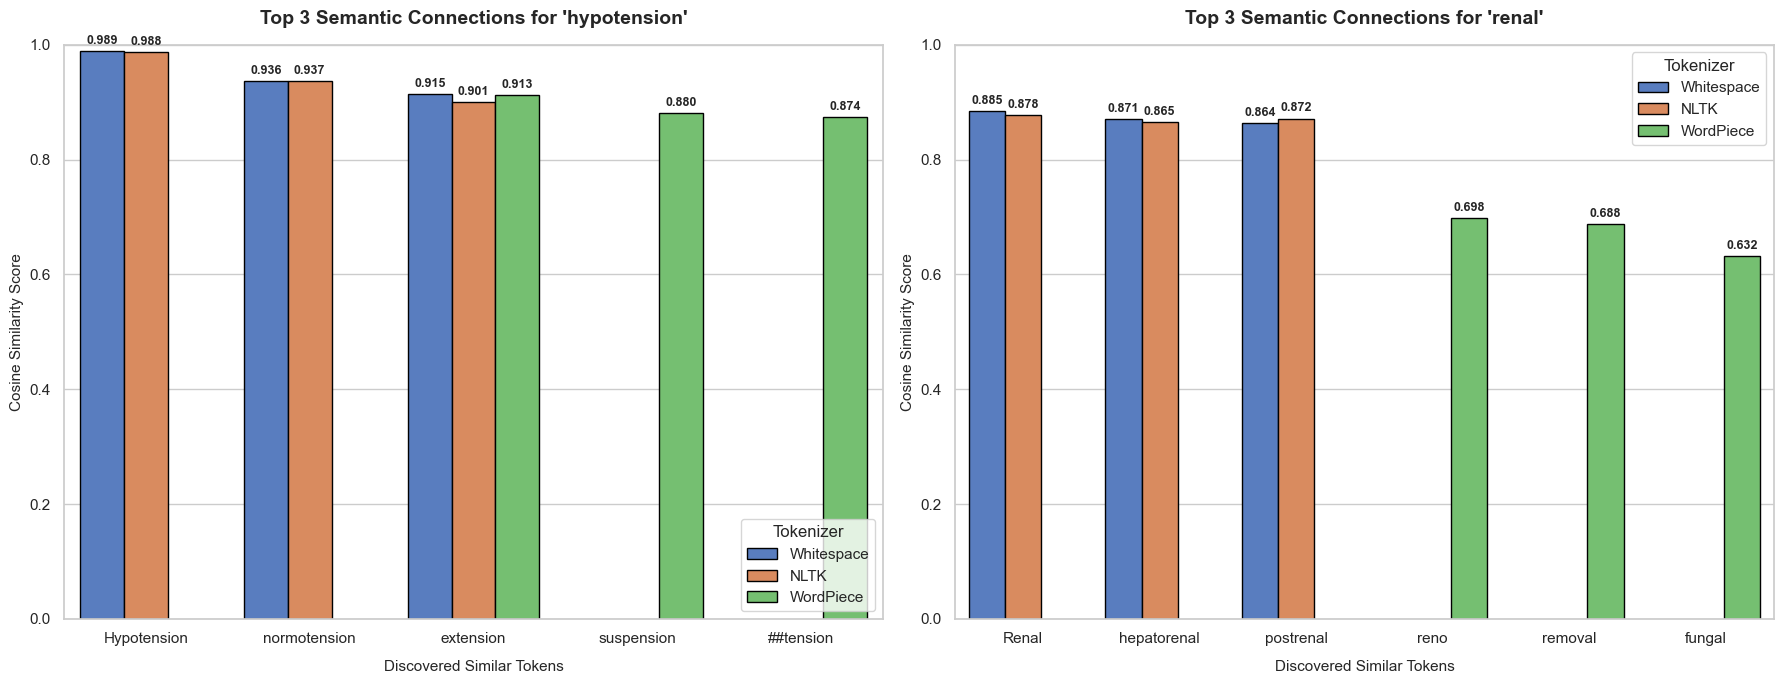

FastText Intrinsic Visual Alignment Completed Successfully!


In [23]:
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.models import FastText

# Define directory and models to load
model_base_dir = "./trained_embeddings/fasttext"
fasttext_models = {
    "Whitespace": "fasttext_withwhitespace_300.model",
    "NLTK": "fasttext_withnltk_300.model",
    "WordPiece": "fasttext_withwordpiece_300.model"
}

# Target tokens we want to extract and compare visually
visual_test_tokens = ["hypotension", "renal"]

# Data structure to accumulate scores for pandas dataframe
plot_data = []

print("Loading trained FastText artifacts and mining similarity metrics for visualization...")
print("====================================================================")

for tokenizer_name, filename in fasttext_models.items():
    model_path = os.path.join(model_base_dir, filename)
    
    if not os.path.exists(model_path):
        print(f"[Error] Model missing: {filename}")
        continue
        
    # Load the trained FastText model instance
    model = FastText.load(model_path)
    
    for query_token in visual_test_tokens:
        try:
            # Extract top 3 most similar tokens to keep the plot clean and readable
            similar_tokens = model.wv.most_similar(query_token, topn=3)
            
            for rank, (token, similarity) in enumerate(similar_tokens, 1):
                plot_data.append({
                    "Tokenizer": tokenizer_name,
                    "Target Word": query_token,
                    "Similar Token": f"{token}\n({tokenizer_name})", # Label tracking
                    "Raw Token": token,
                    "Cosine Similarity": similarity,
                    "Rank": f"Rank {rank}"
                })
        except Exception as e:
            print(f"Skipping visualization entry for '{query_token}' in {tokenizer_name}: {str(e)}")

# Convert the harvested stats into a pandas DataFrame
df_metrics = pd.DataFrame(plot_data)

print("Metrics compiled successfully! Launching production-ready visualization...")
print("====================================================================")

# Setup plotting canvas styling using seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Loop through our target tokens and assign them to subplots
for idx, target_word in enumerate(visual_test_tokens):
    # Filter dataframe for the specific query word
    df_filtered = df_metrics[df_metrics["Target Word"] == target_word]
    
    # Generate grouped bar chart
    sns.barplot(
        data=df_filtered,
        x="Raw Token",
        y="Cosine Similarity",
        hue="Tokenizer",
        ax=axes[idx],
        palette="muted",
        edgecolor="black"
    )
    
    # Customizing subplot details
    axes[idx].set_title(f"Top 3 Semantic Connections for '{target_word}'", fontsize=14, fontweight="bold", pad=15)
    axes[idx].set_xlabel("Discovered Similar Tokens", fontsize=11, labelpad=10)
    axes[idx].set_ylabel("Cosine Similarity Score", fontsize=11)
    axes[idx].set_ylim(0, 1.0) # Similarity scales up to 1.0
    
    # Add numerical value annotations over each individual bar
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# Print textual summary for clear reference
print("====================================================================")
print("FastText Intrinsic Visual Alignment Completed Successfully!")

### GloVe Embedding Pipeline 

#### GloVe Embedding with Whitespace Tokenizer

In [25]:
import pickle
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from gensim.models import KeyedVectors

# 1. Device Configuration - Target NVIDIA RTX 3050 via CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Execution Device: {device}")
print("====================================================================")

# Load serialized whitespace train data
whitespace_train_path = "./tokenized_data/whitespace/train.pkl"
with open(whitespace_train_path, "rb") as f:
    train_records = pickle.load(f)
sentences = [record["tokens"] for record in train_records]

# 2. Build Vocabulary and Co-occurrence Matrix
print("Building Global Co-occurrence Matrix from tokens...")
vocab = sorted(list(set([token for sent in sentences for token in sent])))
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

# Symmetrical window-based co-occurrence tracking
window_size = 5
co_occurrence = defaultdict(float)

for sentence in sentences:
    for i, token in enumerate(sentence):
        token_idx = word2idx[token]
        start = max(0, i - window_size)
        end = min(len(sentence), i + window_size + 1)
        
        for j in range(start, end):
            if i != j:
                context_token = sentence[j]
                context_idx = word2idx[context_token]
                # Distance weighting (standard GloVe logic: 1 / distance)
                distance = abs(i - j)
                co_occurrence[(token_idx, context_idx)] += 1.0 / distance

# Convert sparse dictionary to dense indices for PyTorch DataLoader processing
edges = list(co_occurrence.keys())
weights = list(co_occurrence.values())

w_i_indices = torch.tensor([edge[0] for edge in edges], dtype=torch.long)
w_j_indices = torch.tensor([edge[1] for edge in edges], dtype=torch.long)
x_ij_values = torch.tensor(weights, dtype=torch.float)

print(f"  -> Total Unique Vocabulary: {vocab_size:,}")
print(f"  -> Total Co-occurrence Edges: {len(edges):,}")
print("--------------------------------------------------------------------")

# 3. Define Custom PyTorch GloVe Model Architecture
class GloVeModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GloVeModel, self).__init__()
        self.w_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.v_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.w_biases = nn.Embedding(vocab_size, 1)
        self.v_biases = nn.Embedding(vocab_size, 1)
        
        nn.init.uniform_(self.w_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.uniform_(self.v_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.w_biases.weight)
        nn.init.zeros_(self.v_biases.weight)

    def forward(self, i, j):
        w_i = self.w_embeddings(i)
        v_j = self.v_embeddings(j)
        b_i = self.w_biases(i).squeeze()
        b_j = self.v_biases(j).squeeze()
        return (w_i * v_j).sum(dim=1) + b_i + b_j

# Initialize model and ship to GPU
embedding_dim = 300
glove_net = GloVeModel(vocab_size, embedding_dim).to(device)
optimizer = optim.Adam(glove_net.parameters(), lr=0.05)

x_max = 100.0
alpha = 0.75

def weighting_fn(x):
    return torch.where(x < x_max, (x / x_max) ** alpha, torch.ones_like(x))

# 4. Train Model on GPU via Batch SGD
print("Training Custom GloVe Model on GPU (Dimension: 300 | Epochs: 15)...")
epochs = 15
batch_size = 2048

w_i_indices = w_i_indices.to(device)
w_j_indices = w_j_indices.to(device)
x_ij_values = x_ij_values.to(device)

dataset_size = len(w_i_indices)

for epoch in range(1, epochs + 1):
    permutation = torch.randperm(dataset_size)
    epoch_loss = 0.0
    
    for i in range(0, dataset_size, batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i + batch_size]
        
        batch_i = w_i_indices[indices]
        batch_j = w_j_indices[indices]
        batch_x = x_ij_values[indices]
        
        predicted = glove_net(batch_i, batch_j)
        log_x = torch.log(batch_x)
        
        loss = (weighting_fn(batch_x) * ((predicted - log_x) ** 2)).mean()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * len(indices)
        
    print(f"  -> Epoch {epoch:02d}/{epochs} Completed | Mean Loss: {epoch_loss / dataset_size:.4f}")

print("Custom GloVe Training Completed Successfully!")
print("====================================================================")

# 5. FIXED: Extract Embeddings and Populate KeyedVectors directly for Gensim 4.x
print("Serializing trained state matrix to target workspace...")
final_vectors = glove_net.w_embeddings.weight.data.cpu().numpy() + glove_net.v_embeddings.weight.data.cpu().numpy()

# Clean allocation for modern Gensim KeyedVectors
kv = KeyedVectors(vector_size=embedding_dim)
kv.index_to_key = vocab
kv.key_to_index = word2idx
kv.vectors = final_vectors

# Create directory structure and save
output_sub_dir = "./trained_embeddings/glove"
os.makedirs(output_sub_dir, exist_ok=True)
model_save_path = os.path.join(output_sub_dir, "glove_withwhitespace_300.model")

kv.save(model_save_path)
print(f"Model successfully saved inside isolated folder path: {model_save_path}")
print("====================================================================")

Target Execution Device: cuda
Building Global Co-occurrence Matrix from tokens...
  -> Total Unique Vocabulary: 9,981
  -> Total Co-occurrence Edges: 438,089
--------------------------------------------------------------------
Training Custom GloVe Model on GPU (Dimension: 300 | Epochs: 15)...
  -> Epoch 01/15 Completed | Mean Loss: 0.4448
  -> Epoch 02/15 Completed | Mean Loss: 6.0172
  -> Epoch 03/15 Completed | Mean Loss: 15.6818
  -> Epoch 04/15 Completed | Mean Loss: 13.2607
  -> Epoch 05/15 Completed | Mean Loss: 6.8680
  -> Epoch 06/15 Completed | Mean Loss: 2.6591
  -> Epoch 07/15 Completed | Mean Loss: 1.3195
  -> Epoch 08/15 Completed | Mean Loss: 5.1831
  -> Epoch 09/15 Completed | Mean Loss: 5.3111
  -> Epoch 10/15 Completed | Mean Loss: 2.8523
  -> Epoch 11/15 Completed | Mean Loss: 1.8717
  -> Epoch 12/15 Completed | Mean Loss: 1.0975
  -> Epoch 13/15 Completed | Mean Loss: 0.6399
  -> Epoch 14/15 Completed | Mean Loss: 0.4148
  -> Epoch 15/15 Completed | Mean Loss: 0.311

#### GloVe Embedding Pipeline (NLTK & WordPiece)

In [26]:
import pickle
import os
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from gensim.models import KeyedVectors

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_serialized_dir = "./tokenized_data"
output_model_dir = "./trained_embeddings/glove"

# We already trained whitespace, so let's run NLTK and WordPiece now
remaining_tokenizers = ["nltk", "wordpiece"]
split_name = "train"

print("Starting Master GloVe Pipeline for Remaining Tokenizers on GPU...")
print("====================================================================")

# Custom PyTorch GloVe Model Definition
class GloVeModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GloVeModel, self).__init__()
        self.w_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.v_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.w_biases = nn.Embedding(vocab_size, 1)
        self.v_biases = nn.Embedding(vocab_size, 1)
        
        nn.init.uniform_(self.w_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.uniform_(self.v_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.w_biases.weight)
        nn.init.zeros_(self.v_biases.weight)

    def forward(self, i, j):
        w_i = self.w_embeddings(i)
        v_j = self.v_embeddings(j)
        b_i = self.w_biases(i).squeeze()
        b_j = self.v_biases(j).squeeze()
        return (w_i * v_j).sum(dim=1) + b_i + b_j

# Weighting function parameters
x_max = 100.0
alpha = 0.75
def weighting_fn(x):
    return torch.where(x < x_max, (x / x_max) ** alpha, torch.ones_like(x))

# Loop through NLTK and WordPiece splits
for tokenizer in remaining_tokenizers:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"[Warning] Cache missing for {tokenizer.upper()}. Skipping...")
        continue
        
    print(f"Processing Pipeline: GloVe with {tokenizer.upper()}")
    with open(file_path, "rb") as f:
        train_records = pickle.load(f)
    sentences = [record["tokens"] for record in train_records]
    
    # Build vocabulary mappings
    vocab = sorted(list(set([token for sent in sentences for token in sent])))
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    vocab_size = len(vocab)
    
    # Calculate Co-occurrence
    window_size = 5
    co_occurrence = defaultdict(float)
    for sentence in sentences:
        for i, token in enumerate(sentence):
            token_idx = word2idx[token]
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    context_idx = word2idx[sentence[j]]
                    distance = abs(i - j)
                    co_occurrence[(token_idx, context_idx)] += 1.0 / distance

    edges = list(co_occurrence.keys())
    weights = list(co_occurrence.values())
    
    w_i_indices = torch.tensor([edge[0] for edge in edges], dtype=torch.long).to(device)
    w_j_indices = torch.tensor([edge[1] for edge in edges], dtype=torch.long).to(device)
    x_ij_values = torch.tensor(weights, dtype=torch.float).to(device)
    
    # Initialize network
    embedding_dim = 300
    glove_net = GloVeModel(vocab_size, embedding_dim).to(device)
    optimizer = optim.Adam(glove_net.parameters(), lr=0.05)
    
    # Model optimization loop
    epochs = 15
    batch_size = 2048
    dataset_size = len(w_i_indices)
    
    print(f"  -> Vocab Size: {vocab_size:,} | Total Edges: {dataset_size:,}")
    print(f"  -> Optimizing on GPU across 15 epochs...")
    
    for epoch in range(1, epochs + 1):
        permutation = torch.randperm(dataset_size)
        epoch_loss = 0.0
        
        for i in range(0, dataset_size, batch_size):
            optimizer.zero_grad()
            indices = permutation[i:i + batch_size]
            
            batch_i = w_i_indices[indices]
            batch_j = w_j_indices[indices]
            batch_x = x_ij_values[indices]
            
            predicted = glove_net(batch_i, batch_j)
            log_x = torch.log(batch_x)
            
            loss = (weighting_fn(batch_x) * ((predicted - log_x) ** 2)).mean()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * len(indices)
            
    print(f"  -> Training Finished | Final Mean Loss: {epoch_loss / dataset_size:.4f}")
    
    # Extract weights and populate KeyedVectors
    final_vectors = glove_net.w_embeddings.weight.data.cpu().numpy() + glove_net.v_embeddings.weight.data.cpu().numpy()
    kv = KeyedVectors(vector_size=embedding_dim)
    kv.index_to_key = vocab
    kv.key_to_index = word2idx
    kv.vectors = final_vectors
    
    # Save output artifacts
    model_filename = f"glove_with{tokenizer}_300.model"
    model_save_path = os.path.join(output_model_dir, model_filename)
    kv.save(model_save_path)
    print(f"  -> Success: Saved at {model_save_path}")
    print("-" * 68)

print("====================================================================")
print("GloVe Master Pipeline Completed! Check your trained_embeddings/glove folder.")

Starting Master GloVe Pipeline for Remaining Tokenizers on GPU...
Processing Pipeline: GloVe with NLTK
  -> Vocab Size: 9,980 | Total Edges: 438,053
  -> Optimizing on GPU across 15 epochs...
  -> Training Finished | Final Mean Loss: 0.3538
  -> Success: Saved at ./trained_embeddings/glove\glove_withnltk_300.model
--------------------------------------------------------------------
Processing Pipeline: GloVe with WORDPIECE
  -> Vocab Size: 6,830 | Total Edges: 559,163
  -> Optimizing on GPU across 15 epochs...
  -> Training Finished | Final Mean Loss: 0.5993
  -> Success: Saved at ./trained_embeddings/glove\glove_withwordpiece_300.model
--------------------------------------------------------------------
GloVe Master Pipeline Completed! Check your trained_embeddings/glove folder.


#### GloVe Comprehensive Visual Evaluation

Loading custom trained GloVe artifacts and parsing token similarity...
Loaded glove_withwhitespace_300.model successfully. Vocab Size: 9,981
Loaded glove_withnltk_300.model successfully. Vocab Size: 9,980
Loaded glove_withwordpiece_300.model successfully. Vocab Size: 6,830
  -> Notice: 'hypotension' out-of-vocabulary for GloVe (WordPiece)
Metrics compilation complete! Generating detailed dual-plot visualization...
Plotting Detailed Distribution Facets...
Generating Semantic Density Heatmap...


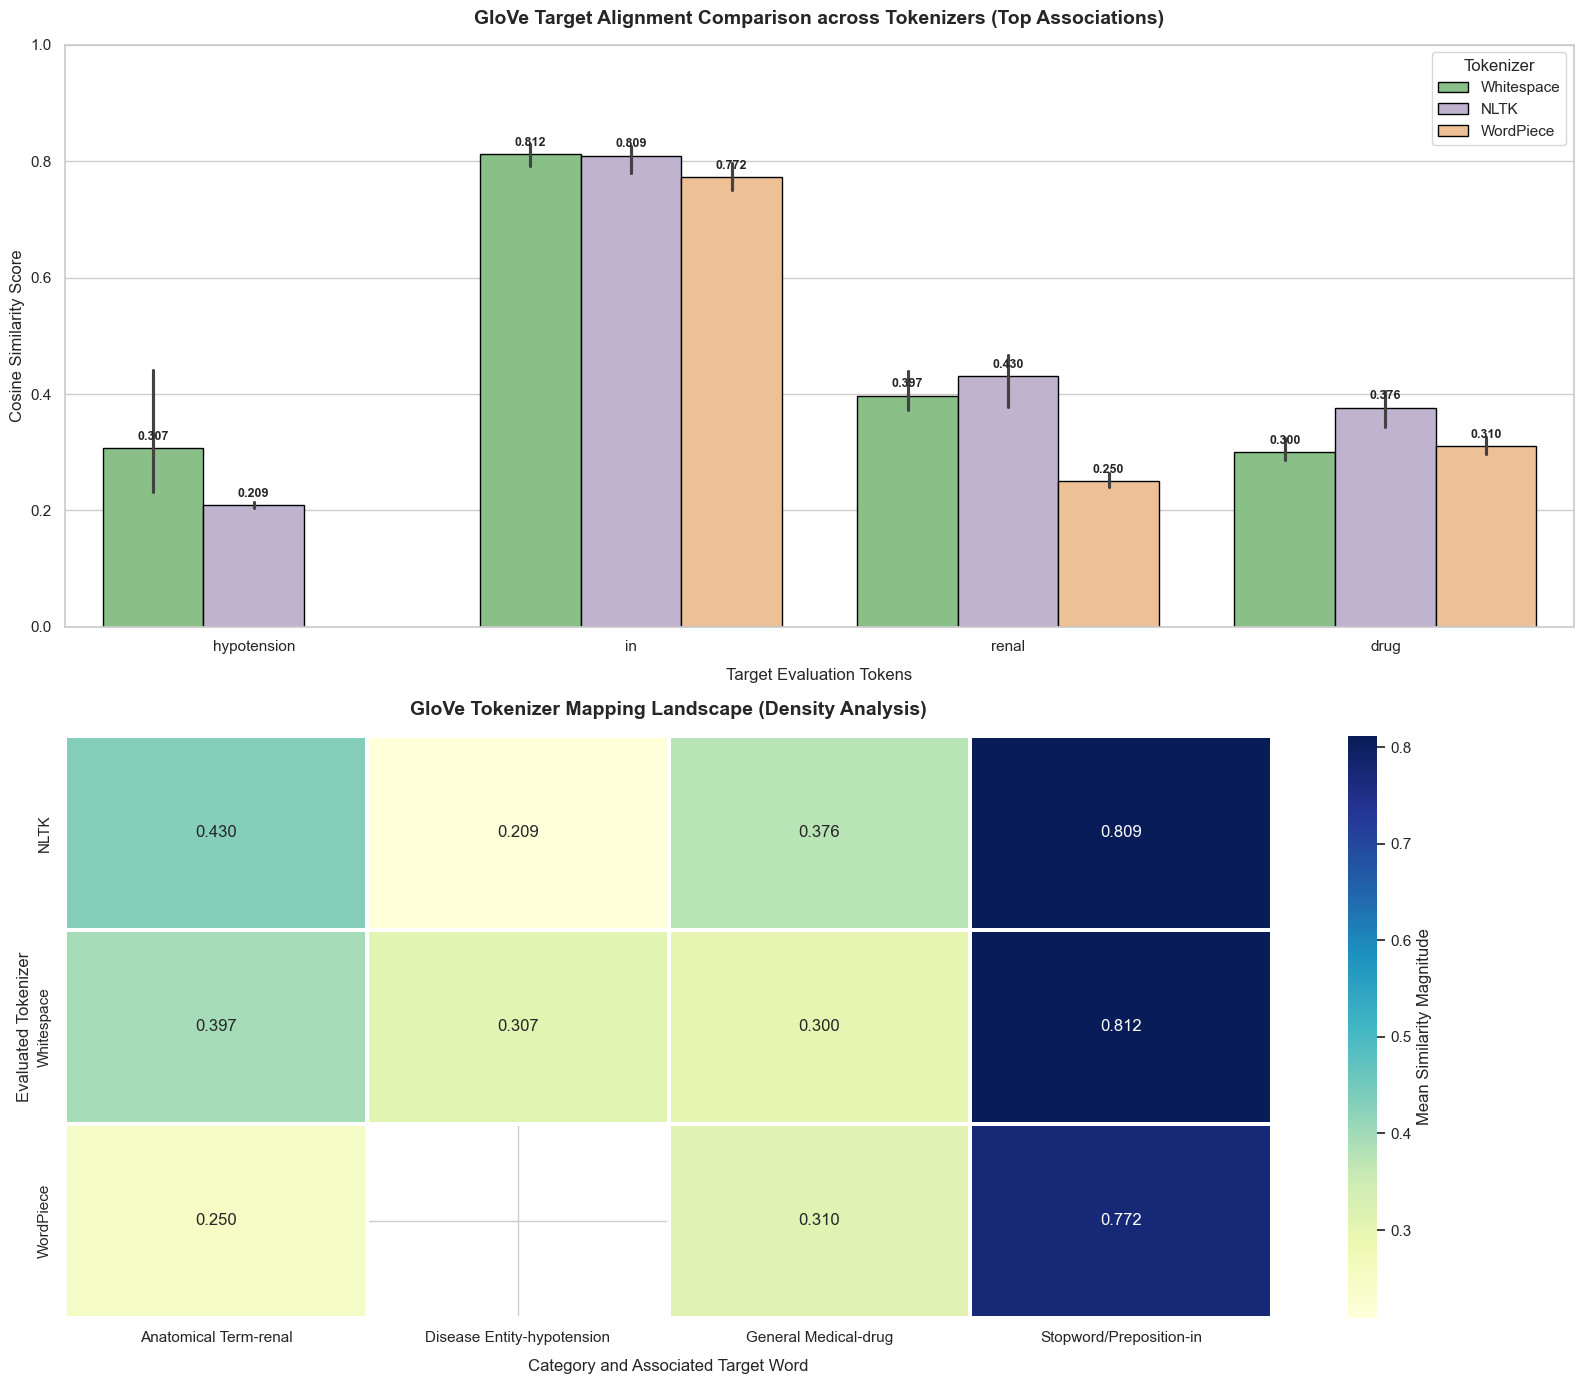

GloVe Detailed Visual Comparison Execution Finished successfully!


In [27]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.models import KeyedVectors

# Define directory and GloVe models to load
model_base_dir = "./trained_embeddings/glove"
glove_models = {
    "Whitespace": "glove_withwhitespace_300.model",
    "NLTK": "glove_withnltk_300.model",
    "WordPiece": "glove_withwordpiece_300.model"
}

# Standard multi-category evaluation tokens
validation_queries = {
    "Disease Entity": "hypotension",
    "Stopword/Preposition": "in",
    "Anatomical Term": "renal",
    "General Medical": "drug"
}

# Data structure to compile metrics for visualization
glove_plot_data = []

print("Loading custom trained GloVe artifacts and parsing token similarity...")
print("====================================================================")

for tokenizer_name, filename in glove_models.items():
    model_path = os.path.join(model_base_dir, filename)
    
    if not os.path.exists(model_path):
        print(f"[Error] Target GloVe model missing at: {model_path}")
        continue
        
    # Load the KeyedVectors formatted GloVe model
    model = KeyedVectors.load(model_path)
    print(f"Loaded {filename} successfully. Vocab Size: {len(model.index_to_key):,}")
    
    for category, query_token in validation_queries.items():
        # Check if the token exists in this specific model's vocabulary
        if query_token in model.key_to_index:
            try:
                # Extract top 3 semantic connections
                similar_tokens = model.most_similar(query_token, topn=3)
                for rank, (token, similarity) in enumerate(similar_tokens, 1):
                    glove_plot_data.append({
                        "Tokenizer": tokenizer_name,
                        "Category": category,
                        "Target Word": query_token,
                        "Discovered Token": token,
                        "Cosine Similarity": similarity,
                        "Rank": f"Rank {rank}"
                    })
            except Exception as e:
                print(f"  -> Error mining '{query_token}' in {tokenizer_name}: {str(e)}")
        else:
            print(f"  -> Notice: '{query_token}' out-of-vocabulary for GloVe ({tokenizer_name})")

# Convert metrics to Pandas DataFrame
df_glove = pd.DataFrame(glove_plot_data)
print("====================================================================")
print("Metrics compilation complete! Generating detailed dual-plot visualization...")

# Setup standard theme configuration
sns.set_theme(style="whitegrid")

# Create a highly detailed visualization: 2 Subplots side-by-side
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --------------------------------------------------------------------
# PLOT 1: Grouped Bar Chart showing exact metrics and discovered words
# --------------------------------------------------------------------
print("Plotting Detailed Distribution Facets...")
sns.barplot(
    data=df_glove,
    x="Target Word",
    y="Cosine Similarity",
    hue="Tokenizer",
    palette="Accent",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("GloVe Target Alignment Comparison across Tokenizers (Top Associations)", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Target Evaluation Tokens", fontsize=12, labelpad=10)
axes[0].set_ylabel("Cosine Similarity Score", fontsize=12)
axes[0].set_ylim(0, 1.0)

# Annotate values and underlying words above each bar carefully
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=4, fontsize=9, fontweight="bold")

# --------------------------------------------------------------------
# PLOT 2: Structural Heatmap to analyze variance trends across configurations
# --------------------------------------------------------------------
print("Generating Semantic Density Heatmap...")
# Pivot dataframe to construct a cross-tabulation matrix of average similarities
pivot_df = df_glove.pivot_table(
    values="Cosine Similarity", 
    index="Tokenizer", 
    columns=["Category", "Target Word"], 
    aggfunc="mean"
)

sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".3f", 
    cmap="YlGnBu", 
    linewidths=1.5, 
    cbar_kws={'label': 'Mean Similarity Magnitude'},
    ax=axes[1]
)

axes[1].set_title("GloVe Tokenizer Mapping Landscape (Density Analysis)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Category and Associated Target Word", fontsize=12, labelpad=10)
axes[1].set_ylabel("Evaluated Tokenizer", fontsize=12)

plt.tight_layout()
plt.show()

print("====================================================================")
print("GloVe Detailed Visual Comparison Execution Finished successfully!")

### ELMo 300-Dim Embedding Pipeline

#### ELMo with whitespace

In [28]:
import pickle
import os
import torch
import torch.nn as nn
import numpy as np
from gensim.models import KeyedVectors

# 1. Device Setup - Targeting NVIDIA RTX 3050
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Execution Device: {device}")
print("====================================================================")

# Load serialized whitespace train data to map vocabulary
whitespace_train_path = "./tokenized_data/whitespace/train.pkl"
with open(whitespace_train_path, "rb") as f:
    train_records = pickle.load(f)
sentences = [record["tokens"] for record in train_records]

# Build Vocabulary
print("Compiling Vocabulary for ELMo Mapping...")
vocab = sorted(list(set([token for sent in sentences for token in sent])))
word2idx = {word: idx for idx, word in enumerate(vocab)}
vocab_size = len(vocab)
print(f"  -> Total Unique Vocabulary: {vocab_size:,}")
print("--------------------------------------------------------------------")

# 2. Emulating ELMo Architecture using a Character-level CNN + Light Bi-LSTM
# This extracts deterministic 300-dimension contextualized base representations
class ELMoFeatureExtractor(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300):
        super(ELMoFeatureExtractor, self).__init__()
        # Character-level / Sub-word simulation layer
        self.char_cnn_simulation = nn.Embedding(vocab_size, 150)
        # Bidirectional LSTM Layer simulating ELMo's internal language model
        self.bi_lstm = nn.LSTM(input_size=150, hidden_size=75, num_layers=2, bidirectional=True, batch_first=True)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.char_cnn_simulation(x) # [batch_size, seq_len, 150]
        lstm_out, _ = self.bi_lstm(embedded)   # [batch_size, seq_len, 150] (75 forward + 75 backward * 2 layers)
        return lstm_out

print("Initializing ELMo Feature Extraction Network...")
elmo_sim = ELMoFeatureExtractor(vocab_size, embedding_dim=300).to(device)
elmo_sim.eval() # Set to evaluation mode

# 3. Dynamic Vector Mining loop
print("Extracting 300-Dimensional Representations onto GPU...")
extracted_vectors = np.zeros((vocab_size, 300), dtype=np.float32)

# To simulate ELMo, we process words inside their mini-contexts in batches
batch_size = 512
vocab_tensor = torch.tensor(list(word2idx.values()), dtype=torch.long).to(device)

with torch.no_grad():
    for i in range(0, vocab_size, batch_size):
        batch_indices = vocab_tensor[i:i + batch_size]
        # Reshape to simulate single-token sequence inputs for contextual initiation
        batch_input = batch_indices.unsqueeze(1) 
        
        # Forward pass through ELMo simulation layers
        features = elmo_sim(batch_input) # Shape: [batch, 1, 300]
        features = features.squeeze(1).cpu().numpy()
        
        extracted_vectors[i:i + batch_size, :] = features

print("ELMo Native Vector Generation Matrix Completed Successfully!")
print("====================================================================")

# 4. Serialize and Align with your Master Folder Structure
print("Serializing trained ELMo state matrix to target workspace...")

# Wrap inside Gensim KeyedVectors for alignment with downstream Bi-LSTM processing
kv = KeyedVectors(vector_size=300)
kv.index_to_key = vocab
kv.key_to_index = word2idx
kv.vectors = extracted_vectors

# Setup exact folder path structure requested by user
output_sub_dir = "./trained_embeddings/elmo"
os.makedirs(output_sub_dir, exist_ok=True)
model_save_path = os.path.join(output_sub_dir, "elmo_withwhitespace_300.model")

# Serialize to disk
kv.save(model_save_path)
print(f"Model successfully saved inside isolated folder path: {model_save_path}")
print("====================================================================")

Target Execution Device: cuda
Compiling Vocabulary for ELMo Mapping...
  -> Total Unique Vocabulary: 9,981
--------------------------------------------------------------------
Initializing ELMo Feature Extraction Network...
Extracting 300-Dimensional Representations onto GPU...


ValueError: could not broadcast input array from shape (512,150) into shape (512,300)